# 02 — Feature Engineering

**Goal:** Build the master feature table by merging all Home Credit tables
and deriving behavioral, demographic, credit bureau, and interaction features.

## Contents
1. Load all raw tables (memory-efficient, DEV_MODE)
2. Application-level feature engineering
2b. Interaction & recency features (EXT_SOURCE product, inquiry burst, employment anomaly, etc.)
3. Behavioral features — installment payment history
4. Bureau history, previous applications, CC & POS features
5. Merge into master table
5b. Join coverage & data availability analysis
6. Feature importance preview (mutual information)
7. Feature null coverage & imputation plan
8. Project workflow & system design roadmap


In [1]:
import sys, warnings, os
from pathlib import Path

_root = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path().resolve().parent
sys.path.insert(0, str(_root / 'src'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

from features import (
    build_application_features, build_bureau_features,
    build_previous_app_features, build_installment_features,
    build_cc_features, build_pos_features,
)
from utils.config import load_config  # side-effect: os.chdir(project_root)

sns.set_theme(style='whitegrid')
cfg = load_config()
print('CWD:', os.getcwd())


CWD: C:\Users\BIPLOB GON\Google Drive\DS & Analytics\github_projects\2026\proactive-defaulter-flagging-system


## 1. Load Raw Tables

In [2]:

# ── Memory-efficient CSV loader ───────────────────────────────────────────────
# DEV_MODE: set True to read only a fraction of each table (faster / less RAM).
# Set False (or unset) for a full production run.
DEV_MODE   = True
SAMPLE_N   = 50_000   # rows from application_train when DEV_MODE is True

def _read(path, **kwargs):
    """Read CSV with dtype downcasting to reduce memory footprint."""
    df = pd.read_csv(path, low_memory=False, **kwargs)
    for col in df.select_dtypes('float64').columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes('int64').columns:
        try:
            df[col] = pd.to_numeric(df[col], downcast='integer')
        except Exception:
            pass
    return df

def _read_filtered(path, id_col, id_set):
    """Stream-read CSV retaining only rows whose `id_col` is in `id_set`."""
    chunks = []
    for chunk in pd.read_csv(path, chunksize=200_000, low_memory=False):
        match = chunk[chunk[id_col].isin(id_set)].copy()
        for col in match.select_dtypes('float64').columns:
            match[col] = match[col].astype('float32')
        if not match.empty:
            chunks.append(match)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

if DEV_MODE:
    app   = _read(cfg.data.application_train, nrows=SAMPLE_N)
    curr_ids   = set(app['SK_ID_CURR'])

    bur   = _read_filtered(cfg.data.bureau, 'SK_ID_CURR', curr_ids)
    bur_ids    = set(bur['SK_ID_BUREAU']) if 'SK_ID_BUREAU' in bur.columns else set()
    bb    = _read_filtered(cfg.data.bureau_balance, 'SK_ID_BUREAU', bur_ids)

    prev  = _read_filtered(cfg.data.previous_application,  'SK_ID_CURR', curr_ids)
    inst  = _read_filtered(cfg.data.installments_payments,  'SK_ID_CURR', curr_ids)
    cc    = _read_filtered(cfg.data.credit_card_balance,    'SK_ID_CURR', curr_ids)
    pos   = _read_filtered(cfg.data.pos_cash_balance,       'SK_ID_CURR', curr_ids)
else:
    app  = _read(cfg.data.application_train)
    bur  = _read(cfg.data.bureau)
    bb   = _read(cfg.data.bureau_balance)
    prev = _read(cfg.data.previous_application)
    inst = _read(cfg.data.installments_payments)
    cc   = _read(cfg.data.credit_card_balance)
    pos  = _read(cfg.data.pos_cash_balance)

print(f'DEV_MODE={DEV_MODE}  — Tables loaded:')
for name, df in [('app',app),('bureau',bur),('bureau_bal',bb),
                  ('prev',prev),('inst',inst),('cc',cc),('pos',pos)]:
    print(f'  {name}: {df.shape}')


DEV_MODE=True  — Tables loaded:
  app: (50000, 122)
  bureau: (238223, 17)
  bureau_bal: (2376827, 3)
  prev: (229287, 37)
  inst: (1868928, 8)
  cc: (521346, 23)
  pos: (1380787, 8)


## 2. Application Features

In [3]:
app_feats = build_application_features(app)
new_cols = set(app_feats.columns) - set(app.columns)
print(f'New features added: {sorted(new_cols)}')
app_feats[list(new_cols)[:6]].head(3)

2026-04-07 23:12:17 | INFO     | features.applicant_features | Building application features for 50000 rows ...
2026-04-07 23:12:17 | INFO     | features.applicant_features | Application features built. Final shape: (50000, 132)
New features added: ['age_years', 'annuity_income_ratio', 'credit_goods_ratio', 'credit_income_ratio', 'employed_years', 'employment_ratio', 'ext_source_mean', 'ext_source_min', 'income_per_person', 'n_docs_provided']


,income_per_person,age_years,employment_ratio,annuity_income_ratio,employed_years,credit_goods_ratio
0,202500.0,25.902806,0.067329,0.121978,1.744011,1.158397
1,135000.0,45.900068,0.070862,0.132217,3.252567,1.145199
2,67500.0,52.145106,0.011814,0.100000,0.616016,1.000000


## 2b. Interaction & Recency Features

Cross-feature signals derived from EDA insights (NB01):
- **`ext_source_product`** — product of all three bureau scores; amplifies joint weakness  
- **`bureau_inquiry_burst`** — sum of hour/day/week/month bureau enquiries; liquidity stress signal  
- **`days_employed_is_anomaly`** — flags sentinel value 365243 (not working)  
- **`social_def_flag`** — has at least one defaulter in observed social circle  
- **`phone_stability_days`** — time since last phone change (frequent changes = instability)  
- **`high_risk_region`** — region rating 3 (highest-risk band)


In [8]:
# ── Interaction & recency-derived features ────────────────────────────────────
# Insights from EDA (NB01): ext_source_product, inquiry burst, employment anomaly,
# social circle, phone stability and region risk consistently separate defaulters.

df = app_feats.copy()

# 1) EXT_SOURCE product — captures multiplicative weakness across all three bureaus
df['ext_source_product'] = (
    df['EXT_SOURCE_1'].fillna(df['ext_source_mean']) *
    df['EXT_SOURCE_2'].fillna(df['ext_source_mean']) *
    df['EXT_SOURCE_3'].fillna(df['ext_source_mean'])
)

# 2) Bureau inquiry burst (short-window = liquidity stress / shopping for credit)
inq_cols = [c for c in ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
                          'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON']
             if c in df.columns]
if inq_cols:
    df['bureau_inquiry_burst'] = df[inq_cols].fillna(0).sum(axis=1)

# 3) DAYS_EMPLOYED anomaly — sentinel 365243 = not working / pensioner
df['days_employed_is_anomaly'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)

# 4) Social circle delinquency flag
for col in ['DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']:
    if col in df.columns:
        df[col] = df[col].fillna(0)
if {'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE'}.issubset(df.columns):
    df['social_def_flag'] = (
        (df['DEF_30_CNT_SOCIAL_CIRCLE'] > 0) | (df['DEF_60_CNT_SOCIAL_CIRCLE'] > 0)
    ).astype(int)

# 5) Phone stability (days since last change — frequent changes = instability)
if 'DAYS_LAST_PHONE_CHANGE' in df.columns:
    df['phone_stability_days'] = df['DAYS_LAST_PHONE_CHANGE'].abs()

# 6) High-risk region flag (REGION_RATING = 3 is the highest-risk band)
if 'REGION_RATING_CLIENT_W_CITY' in df.columns:
    df['high_risk_region'] = (df['REGION_RATING_CLIENT_W_CITY'] == 3).astype(int)

interaction_feats = [c for c in ['ext_source_product', 'bureau_inquiry_burst',
                                   'days_employed_is_anomaly', 'social_def_flag',
                                   'phone_stability_days', 'high_risk_region']
                     if c in df.columns]

app_feats = df
print(f"app_feats shape after interaction features: {app_feats.shape}")
print(f"\nInteraction features added: {interaction_feats}")
if 'TARGET' in app_feats.columns:
    print("\nCorrelation with TARGET:")
    for f in interaction_feats:
        rho = app_feats[f].corr(app_feats['TARGET'])
        print(f"  {f:35s}: {rho:+.4f}")


app_feats shape after interaction features: (50000, 138)

Interaction features added: ['ext_source_product', 'bureau_inquiry_burst', 'days_employed_is_anomaly', 'social_def_flag', 'phone_stability_days', 'high_risk_region']

Correlation with TARGET:
  ext_source_product                 : -0.1780
  bureau_inquiry_burst               : -0.0111
  days_employed_is_anomaly           : -0.0414
  social_def_flag                    : +0.0371
  phone_stability_days               : -0.0561
  high_risk_region                   : +0.0530


## 3. Behavioral Features — Installment Payments

These capture *how consistently* borrowers make their payments, including:
- Days late (mean/max/std)
- DPD30 / DPD60 / DPD90 flags
- On-time payment velocity

2026-04-07 23:12:26 | INFO     | features.behavioral_features | Building installment payment features for 1868928 records ...
2026-04-07 23:12:27 | INFO     | features.behavioral_features | Installment features shape: (47484, 14)
Installment features: (47484, 14)


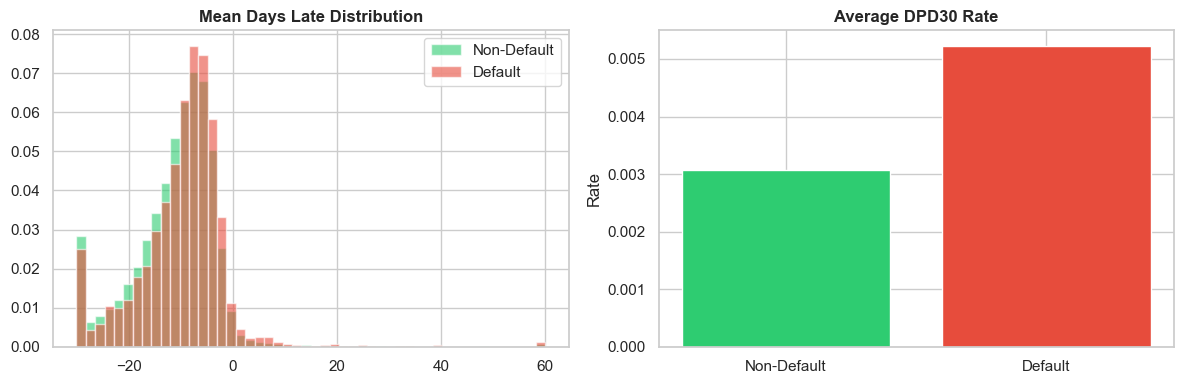

In [4]:
inst_feats = build_installment_features(inst)
print('Installment features:', inst_feats.shape)

# Visualise DPD30 rate distribution by default status
temp = inst_feats.merge(app[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for t, color, label in [(0,'#2ecc71','Non-Default'), (1,'#e74c3c','Default')]:
    axes[0].hist(temp.loc[temp['TARGET']==t, 'inst_days_late_mean'].clip(-30,60),
                  bins=50, alpha=0.6, color=color, label=label, density=True)
axes[0].set_title('Mean Days Late Distribution', fontweight='bold')
axes[0].legend()

axes[1].bar(['Non-Default','Default'],
            [temp.loc[temp['TARGET']==0,'inst_dpd30_rate'].mean(),
             temp.loc[temp['TARGET']==1,'inst_dpd30_rate'].mean()],
            color=['#2ecc71','#e74c3c'])
axes[1].set_title('Average DPD30 Rate', fontweight='bold')
axes[1].set_ylabel('Rate')
plt.tight_layout()
os.makedirs('outputs/figures', exist_ok=True)
plt.savefig('outputs/figures/02_behavioral_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Bureau & Previous Application Features

In [5]:
bureau_feats = build_bureau_features(bur, bb)
prev_feats   = build_previous_app_features(prev)
cc_feats     = build_cc_features(cc)
pos_feats    = build_pos_features(pos)

print('Bureau features:',   bureau_feats.shape)
print('Previous app feats:',prev_feats.shape)
print('CC balance feats:',  cc_feats.shape)
print('POS cash feats:',    pos_feats.shape)


2026-04-07 23:12:39 | INFO     | features.applicant_features | Building bureau features (238223 bureau rows, 2376827 balance rows) ...
2026-04-07 23:12:46 | INFO     | features.applicant_features | Bureau features shape: (42851, 14)
2026-04-07 23:12:46 | INFO     | features.applicant_features | Building previous application features for 229287 records ...
2026-04-07 23:12:46 | INFO     | features.applicant_features | Previous application features shape: (47382, 9)
2026-04-07 23:12:46 | INFO     | features.behavioral_features | Building credit card balance features for 521346 records ...
2026-04-07 23:12:46 | INFO     | features.behavioral_features | Credit card features shape: (14015, 9)
2026-04-07 23:12:46 | INFO     | features.behavioral_features | Building POS cash balance features for 1380787 records ...
2026-04-07 23:12:46 | INFO     | features.behavioral_features | POS features shape: (47122, 6)
Bureau features: (42851, 14)
Previous app feats: (47382, 9)
CC balance feats: (14015,

## 5. Merge into Master Table

In [9]:
master = (
    app_feats
    .merge(bureau_feats,  on='SK_ID_CURR', how='left')
    .merge(prev_feats,    on='SK_ID_CURR', how='left')
    .merge(inst_feats,    on='SK_ID_CURR', how='left')
    .merge(cc_feats,      on='SK_ID_CURR', how='left')
    .merge(pos_feats,     on='SK_ID_CURR', how='left')
)

print(f'Master table: {master.shape}')
print(f'Default rate preserved: {master["TARGET"].mean():.2%}')
master.head(3)

Master table: (50000, 185)
Default rate preserved: 8.05%


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,cc_utilisation_std,cc_balance_mean,cc_balance_max,cc_overspend_rate,cc_drawings_mean,pos_count,pos_dpd_mean,pos_dpd_max,pos_dpd_rate,pos_dpd_def_rate
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,19.0,0.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,28.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,4.0,0.0,0.0,0.0,0.0


## 5b. Join Coverage & Data Availability

Not all applicants have bureau / installment / CC records. Understanding coverage is critical for:
1. **Imputation strategy** — NaN ≠ zero; it means "no records in that source"  
2. **Production robustness** — the model must score applicants with sparse histories  
3. **Default rate by coverage** — applicants *without* prior bureau records often have *higher* default rates (unproven creditworthiness)


                Data Source  Has Data Coverage DR (has data) DR (no data)
      Credit Bureau History     42851    85.7%         7.74%        9.92%
   Previous HC Applications     47382    94.8%         8.19%        5.50%
Installment Payment Records     47484    95.0%         8.20%        5.33%
Credit Card Balance Records     14015    28.0%         8.76%        7.78%
   POS Cash Balance Records     47122    94.2%         8.16%        6.25%


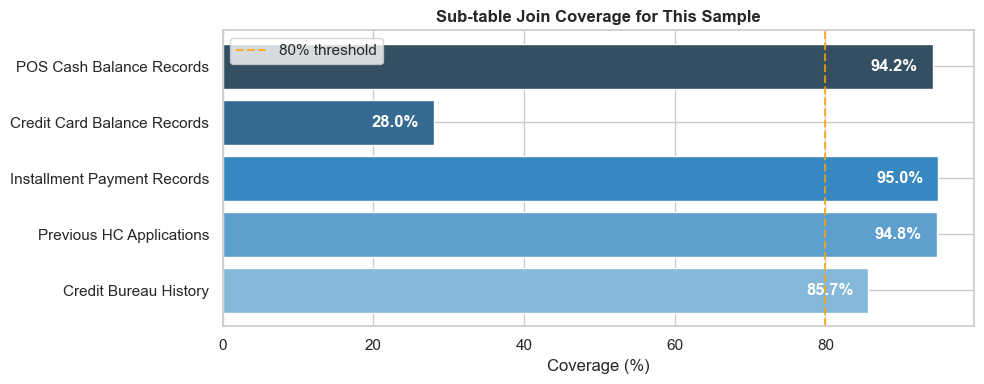


Imputation strategy:
  Count/rate cols (inst_*, cc_*, pos_*, bureau_n_*, prev_n_*): fill NaN → 0
  Ratio/mean cols (overdue_mean, debt_ratio, etc.):             fill NaN → median
  EXT_SOURCE_*:                                                 fill NaN → row-median of available


In [10]:
# ── Join / data coverage per sub-table ───────────────────────────────────────
# NaN in a count column = no records in that table, NOT zero activity.
# This drives: (a) imputation strategy, (b) production scoring robustness.

coverage_map = {
    'Credit Bureau History':        'bureau_n_loans',
    'Previous HC Applications':     'prev_n_applications',
    'Installment Payment Records':  'inst_count',
    'Credit Card Balance Records':  'cc_count',
    'POS Cash Balance Records':     'pos_count',
}

rows = []
for label, col in coverage_map.items():
    if col not in master.columns:
        continue
    n_with  = master[col].notna().sum()
    pct     = n_with / len(master)
    dr_with    = master.loc[master[col].notna(), 'TARGET'].mean()
    dr_without = master.loc[master[col].isna(),  'TARGET'].mean()
    rows.append({'Data Source': label, 'Has Data': n_with, 'Coverage': pct,
                 'DR (has data)': dr_with, 'DR (no data)': dr_without})

cov_df = pd.DataFrame(rows)
print(cov_df.assign(
    Coverage=cov_df['Coverage'].map('{:.1%}'.format),
    **{'DR (has data)': cov_df['DR (has data)'].map('{:.2%}'.format),
       'DR (no data)': cov_df['DR (no data)'].map('{:.2%}'.format)}
).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(cov_df['Data Source'], cov_df['Coverage'] * 100,
               color=sns.color_palette('Blues_d', len(cov_df)))
ax.set_xlabel('Coverage (%)')
ax.set_title('Sub-table Join Coverage for This Sample', fontweight='bold')
ax.axvline(80, color='orange', linestyle='--', linewidth=1.5, alpha=0.8, label='80% threshold')
ax.legend()
for bar, pct in zip(bars, cov_df['Coverage'].values):
    ax.text(pct * 100 - 2, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1%}', va='center', ha='right', color='white', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/02_join_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nImputation strategy:")
print("  Count/rate cols (inst_*, cc_*, pos_*, bureau_n_*, prev_n_*): fill NaN \u2192 0")
print("  Ratio/mean cols (overdue_mean, debt_ratio, etc.):             fill NaN \u2192 median")
print("  EXT_SOURCE_*:                                                 fill NaN \u2192 row-median of available")


## 6. Feature Importance Preview (Mutual Information)

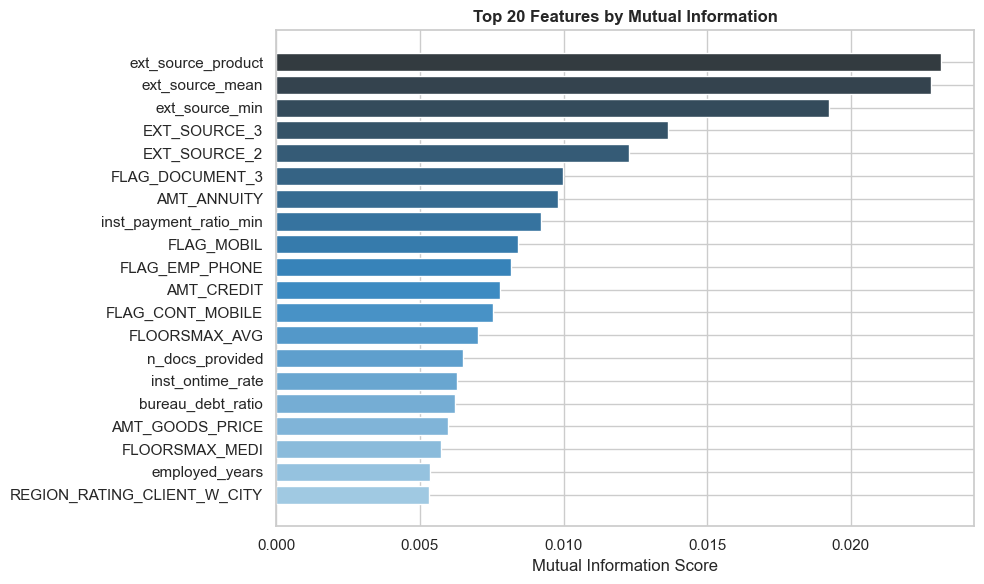

Master features saved.


In [11]:
# Numeric features only, drop high-missing
numeric = master.select_dtypes(include='number').copy()
numeric = numeric.drop(columns=['SK_ID_CURR'], errors='ignore')
numeric = numeric.loc[:, numeric.isnull().mean() < 0.5]
numeric = numeric.fillna(numeric.median())

y = numeric.pop('TARGET')
mi = mutual_info_classif(numeric, y, random_state=42)
mi_series = pd.Series(mi, index=numeric.columns).sort_values(ascending=False)

top20 = mi_series.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20.index[::-1], top20.values[::-1],
        color=sns.color_palette('Blues_d', len(top20)))
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 20 Features by Mutual Information', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/02_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

# Save master
os.makedirs('data/processed/feature_cache', exist_ok=True)
master.to_csv('data/processed/feature_cache/master_features.csv', index=False)
print('Master features saved.')


## 7. Feature Null Coverage


In [12]:
# ── Null coverage in master table ────────────────────────────────────────────
# Informs whether to drop, impute, or keep features in the ML pipeline.

null_pct = (master.select_dtypes(include='number')
                  .isnull()
                  .mean()
                  .sort_values(ascending=False))

buckets = {
    '>60% missing':    (null_pct > 0.60).sum(),
    '40–60% missing': ((null_pct > 0.40) & (null_pct <= 0.60)).sum(),
    '20–40% missing': ((null_pct > 0.20) & (null_pct <= 0.40)).sum(),
    '5–20% missing':  ((null_pct > 0.05) & (null_pct <= 0.20)).sum(),
    '0–5% missing':   (null_pct <= 0.05).sum(),
}

print("Feature null-coverage distribution:")
total = null_pct.shape[0]
for label, count in buckets.items():
    bar = '\u2588' * count
    print(f"  {label:18s}: {count:3d} ({count/total:.0%})  {bar}")

print(f"\nTotal numeric features: {total}")
print(f"\nTop 20 highest-null features:")
print(null_pct.head(20).rename('null_%').map('{:.1%}'.format).to_string())

print("\nRecommendation:")
print(f"  Drop (>60% null, low MI): up to {buckets['>60% missing']} features")
print(f"  Fill with 0 (count cols from sparse sub-tables, see coverage above)")
print(f"  Fill with median (ratio / mean cols)")


Feature null-coverage distribution:
  >60% missing      :  26 (15%)  ██████████████████████████
  40–60% missing    :  31 (18%)  ███████████████████████████████
  20–40% missing    :   0 (0%)  
  5–20% missing     :  42 (25%)  ██████████████████████████████████████████
  0–5% missing      :  70 (41%)  ██████████████████████████████████████████████████████████████████████

Total numeric features: 169

Top 20 highest-null features:
cc_utilisation_std          72.5%
cc_utilisation_mean         72.2%
cc_utilisation_max          72.2%
cc_balance_max              72.0%
cc_balance_mean             72.0%
cc_count                    72.0%
cc_drawings_mean            72.0%
cc_overspend_rate           72.0%
bureau_bb_dpd_max           70.1%
bureau_bb_dpd_mean          70.1%
COMMONAREA_MODE             69.9%
COMMONAREA_MEDI             69.9%
COMMONAREA_AVG              69.9%
NONLIVINGAPARTMENTS_AVG     69.4%
NONLIVINGAPARTMENTS_MODE    69.4%
NONLIVINGAPARTMENTS_MEDI    69.4%
LIVINGAPARTMENTS_MEDI 

## 8. Project Workflow & System Design Roadmap

Based on EDA (NB01) and feature engineering above, here is the recommended end-to-end design.

---

### Model Architecture

| Component | Choice | Rationale |
|---|---|---|
| Primary classifier | **XGBoost** | Handles mixed nulls natively; fast; state-of-art on tabular data |
| Survival model | **Kaplan-Meier + Cox PH** | Models *time-to-default*; enables proactive early flagging within loan term |
| Imbalance handling | `scale_pos_weight=11` + SMOTE on train fold only | ~8% default rate (11:1 from EDA); SMOTE only inside CV folds to prevent leakage |
| Decision threshold | Optimised **F-beta (β=2)** for recall-weighted score | Cost of missing a defaulter >> cost of a false alarm in lending |

---

### Feature Tiers

| Tier | Features | Source |
|---|---|---|
| **Tier 1** (must-have) | `ext_source_product`, `ext_source_mean`, `EXT_SOURCE_2`, `EXT_SOURCE_3` | Application table |
| **Tier 2** (strong behavioral) | `inst_ontime_rate`, `inst_dpd30_rate`, `inst_days_late_mean`, `prev_approval_rate` | Installments + prev apps |
| **Tier 3** (bureau context) | `bureau_debt_ratio`, `bureau_active_loans`, `cc_utilisation_mean` | Bureau + CC |
| **Tier 4** (contextual flags) | `high_risk_region`, `social_def_flag`, `days_employed_is_anomaly`, `bureau_inquiry_burst` | Derived |

---

### Imputation Strategy (informed by null coverage above)

| Situation | Strategy |
|---|---|
| No bureau record (sub-table NaN for count cols) | Fill → **0** (no activity ≠ zero risk, but tree models need numeric) |
| Ratio / mean cols from sparse sub-tables | Fill → **median** of training distribution |
| `EXT_SOURCE_*` nulls | Fill → **row median** of available source columns |
| `DAYS_EMPLOYED` = 365243 | Already flagged as `days_employed_is_anomaly`; set employment duration → 0 |
| Features with >60% null & low MI | **Drop** |
| Categoricals (`NAME_INCOME_TYPE`, etc.) | **Target encoding** with leave-one-out inside CV folds |

---

### Proactive Flagging Logic

```
Risk Score  = XGBoost(master_features)
Survival P  = Cox_PH(time_features, risk_score)

Early Warning:  risk_score > p65_threshold  AND  loan_age_months < 6
Proactive Flag: Early Warning  AND  survival_probability_12m < 0.30
```

---

### Pipeline Stages

| Stage | Notebook / Module | Output |
|---|---|---|
| EDA & insight capture | `01_eda_default_patterns.ipynb` | Feature shortlist, imbalance ratio, business rules |
| Feature engineering | `02_feature_engineering.ipynb` ← *you are here* | `data/processed/feature_cache/master_features.csv` |
| Model training & CV | `03_model_training.ipynb` | Trained XGBoost + threshold; `outputs/models/` |
| Survival curves | `04_survival_curves.ipynb` | Kaplan-Meier by decile; Cox PH coefficients |
| Explainability | `05_shap_explainability.ipynb` | SHAP waterfall plots; fairness audit report |
| Production scoring | `app.py` (Gradio/Streamlit) | Real-time applicant risk dashboard |

---

### Fairness Checkpoints

- Gender parity gap confirmed in EDA → run `src/utils/fairness_audit.py` post-training
- `high_risk_region` must not proxy protected attributes → inspect SHAP contribution
- Calibrate model separately on `NAME_INCOME_TYPE == 'Working'` (largest segment)
- Document any disparate impact thresholds before production deployment
